In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
gdp_df = pd.read_csv('../data/gdp_percapita.csv')

In [3]:
gdp_df

,Country or Area,Year,Value,Value Footnotes
0,Afghanistan,2023,1983.812620,NaN
1,Afghanistan,2022,1981.710168,NaN
2,Afghanistan,2021,2144.166570,NaN
3,Afghanistan,2020,2769.685745,NaN
4,Afghanistan,2019,2927.245144,NaN
...,...,...,...,...
8460,Zimbabwe,1994,6010.742417,NaN
8461,Zimbabwe,1993,5509.083113,NaN
8462,Zimbabwe,1992,5532.037403,NaN
8463,Zimbabwe,1991,6254.274735,NaN


In [4]:
## 5. How many rows and columns are in `gdp_df`? What are the data types of each column?
gdp_df.shape

(8465, 4)

In [5]:
gdp_df.dtypes

Country or Area     object
Year                 int64
Value              float64
Value Footnotes    float64
dtype: object

In [6]:
## 6. Drop the `Value Footnotes` column and rename the remaining three to 'Country', 'Year', and 'GDP_Per_Capita'.
gdp_df = gdp_df.drop(columns = ['Value Footnotes'])

In [160]:
gdp_df = gdp_df.rename(columns={
    'Country or Area': 'Country',
    'Year': 'Year',
    'Value': 'GDP_Per_Capita',
})

In [161]:
gdp_df

,Country,Year,GDP_Per_Capita
0,Afghanistan,2023,1983.812620
1,Afghanistan,2022,1981.710168
2,Afghanistan,2021,2144.166570
3,Afghanistan,2020,2769.685745
4,Afghanistan,2019,2927.245144
...,...,...,...
8460,Zimbabwe,1994,6010.742417
8461,Zimbabwe,1993,5509.083113
8462,Zimbabwe,1992,5532.037403
8463,Zimbabwe,1991,6254.274735


In [167]:
## 7. How many countries have data for all years? 
gdp_df['Year'].nunique()


##OR##

Country_count = gdp_df.Country.value_counts().reset_index()


Country_count.columns = ['Country', 'Count']

In [169]:
len(Country_count) - (Country_count.Count == 35).sum()

np.int64(21)

In [170]:
total_years = gdp_df['Year'].nunique

In [171]:
print(gdp_df.columns.tolist())

['Country', 'Year', 'GDP_Per_Capita']


In [172]:
years_per_country = gdp_df.groupby("Country")["Year"].nunique()

In [173]:
years_per_country

Country
Afghanistan                    24
Africa Eastern and Southern    35
Africa Western and Central     35
Albania                        35
Algeria                        35
                               ..
Virgin Islands (US)            21
West Bank and Gaza             31
World                          35
Zambia                         35
Zimbabwe                       35
Name: Year, Length: 247, dtype: int64

In [174]:
years_per_country[years_per_country == 35]

Country
Africa Eastern and Southern    35
Africa Western and Central     35
Albania                        35
Algeria                        35
Andorra                        35
                               ..
Vanuatu                        35
Viet Nam                       35
World                          35
Zambia                         35
Zimbabwe                       35
Name: Year, Length: 226, dtype: int64

In [175]:
years_per_country[years_per_country == 35].count()

np.int64(226)

In [16]:
total_countries = years_per_country[years_per_country == 35].count()

In [17]:
total_countries

np.int64(226)

In [18]:
##Which countries are missing many years of data?

In [19]:
years_per_country[years_per_country != 35].count()

np.int64(21)

In [20]:
##Look at the number of observations per year. What do you notice? 

In [21]:
first_year = gdp_df.groupby("Country")["Year"].min()

In [22]:
added_countries = first_year[first_year > 1990]

In [23]:
added_countries.head(50)

Country
Afghanistan                  2000
Cayman Islands               2006
CuraÃ§ao                     2000
Djibouti                     2013
Faroe Islands                2008
Kosovo                       2008
Montenegro                   1997
San Marino                   1997
Serbia                       1995
Sint Maarten (Dutch part)    2009
Somalia, Fed. Rep.           1991
Turks and Caicos Islands     2007
Virgin Islands (US)          2002
West Bank and Gaza           1994
Name: Year, dtype: int64

In [24]:
##ANSWER: 
##the amount of observations increases (steadily) from 233 to 245-247 in the last recent years
## 14 new countries were added (not including 1990) to the dataset tracking country GDP

In [25]:
## 8. Create some plots to show the distribution of GDP per capita for the year 2020. 
##Go to the Python Graph Gallery (https://www.python-graph-gallery.com/) and look at the different types of plots under the Distribution section. 
##Create a histogram, a density plot, a boxplot, and a violin plot (See Below)

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [27]:
Data_2020 = gdp_df[gdp_df['Year'] == 2020]

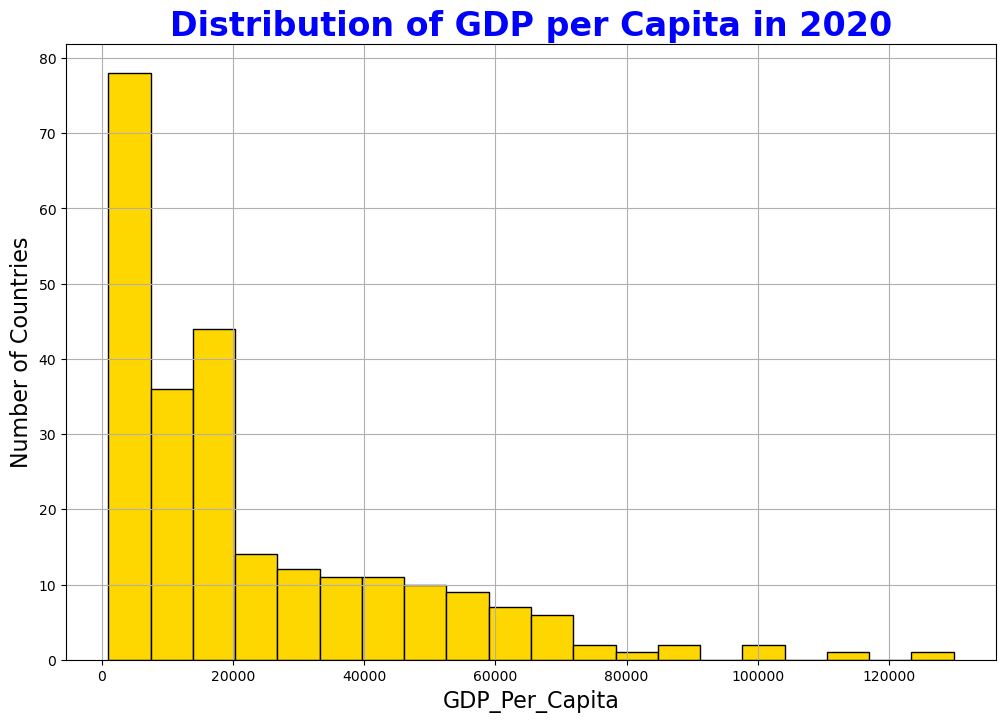

In [28]:
Data_2020['GDP_Per_Capita'].hist(bins=20, edgecolor='black', color='gold', figsize=(12,8))
plt.title('Distribution of GDP per Capita in 2020',fontsize=24, weight='bold',color='Blue')
plt.xlabel('GDP_Per_Capita', fontsize=16)
plt.ylabel('Number of Countries', fontsize=16)
plt.show()

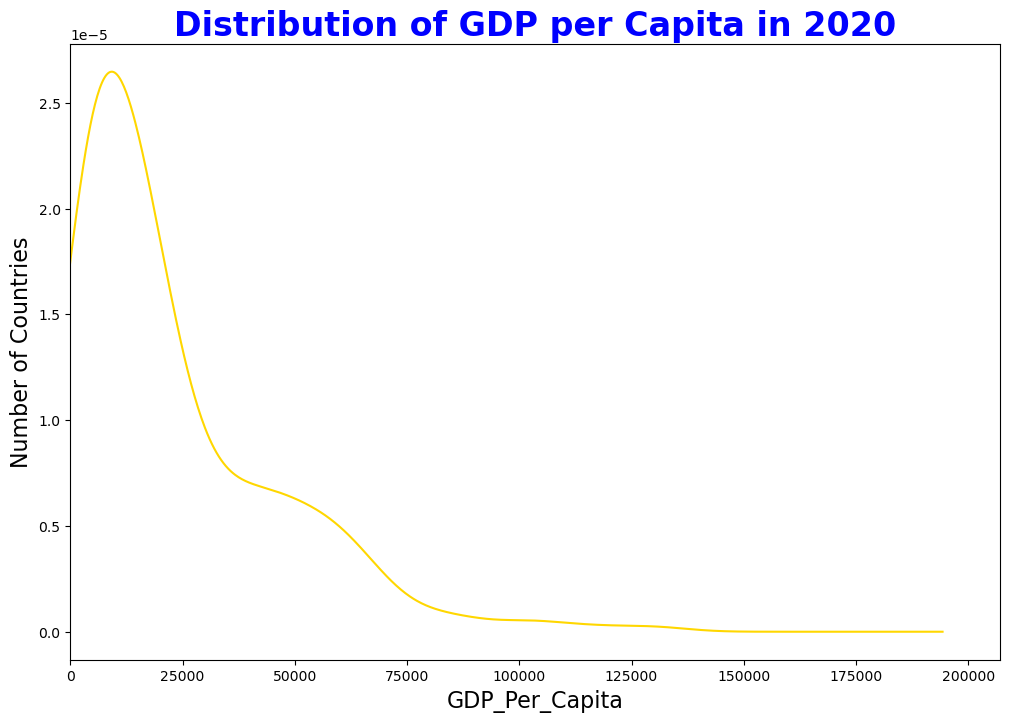

In [29]:
Data_2020['GDP_Per_Capita'].plot.density(color='gold', figsize=(12,8))
plt.title('Distribution of GDP per Capita in 2020',fontsize=24, weight='bold',color='Blue')
plt.xlabel('GDP_Per_Capita', fontsize=16)
plt.ylabel('Number of Countries', fontsize=16)
plt.xlim(left=0)
plt.show() 

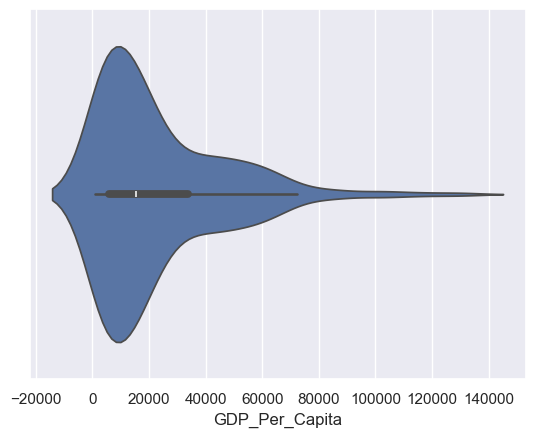

In [179]:
sns.violinplot(data = Data_2020, x = 'GDP_Per_Capita');

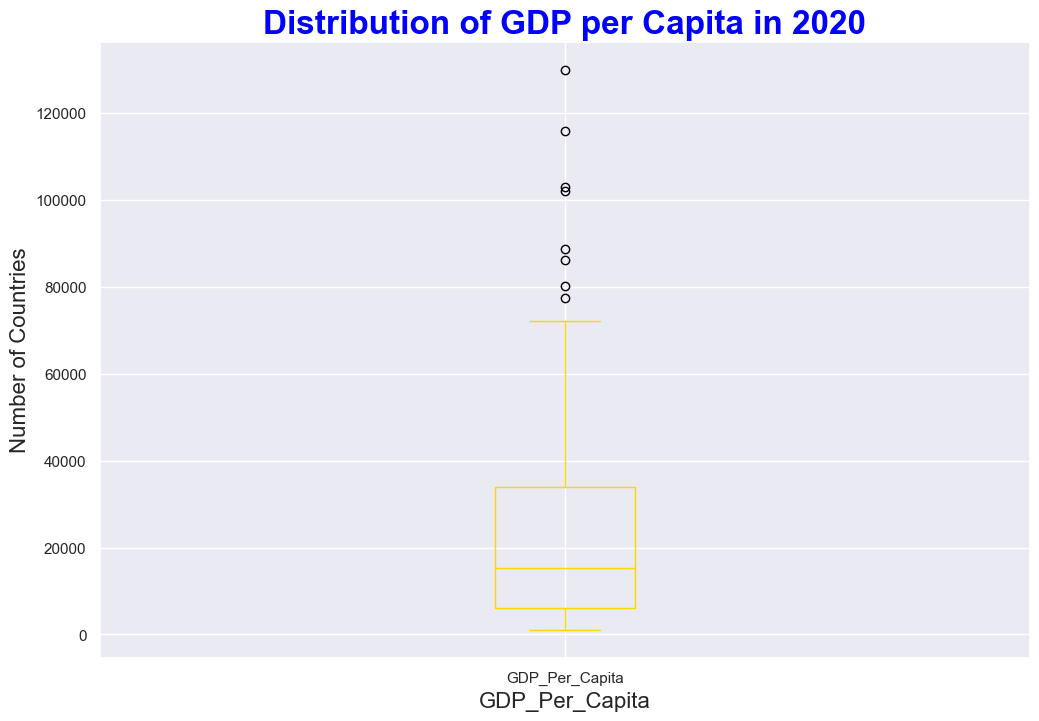

In [177]:
Data_2020['GDP_Per_Capita'].plot.box(color='gold', figsize=(12,8))
plt.title('Distribution of GDP per Capita in 2020',fontsize=24, weight='bold',color='Blue')
plt.xlabel('GDP_Per_Capita', fontsize=16)
plt.ylabel('Number of Countries', fontsize=16)
plt.show() 

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

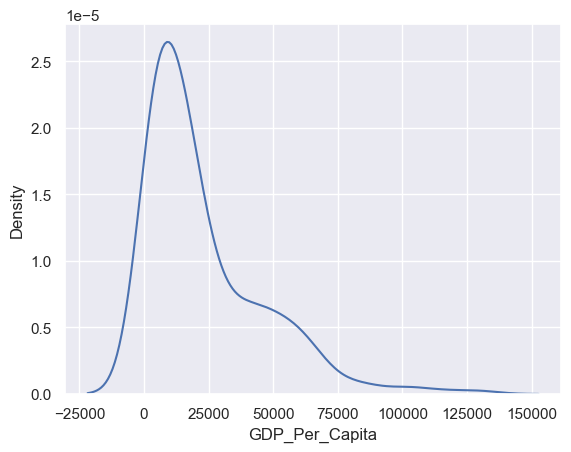

In [183]:
sns.kdeplot(data = Data_2020, x = 'GDP_Per_Capita');

In [185]:
Data_2020.GDP_Per_Capita.median()

15399.308958012449

In [186]:
Data_2020.describe()

,Year,GDP_Per_Capita
count,247.0,247.000000
mean,2020.0,23118.025650
std,0.0,22915.365686
min,2020.0,1030.770264
25%,2020.0,6046.008968
50%,2020.0,15399.308958
75%,2020.0,33899.203031
max,2020.0,129865.629988


<Axes: xlabel='GDP_Per_Capita'>

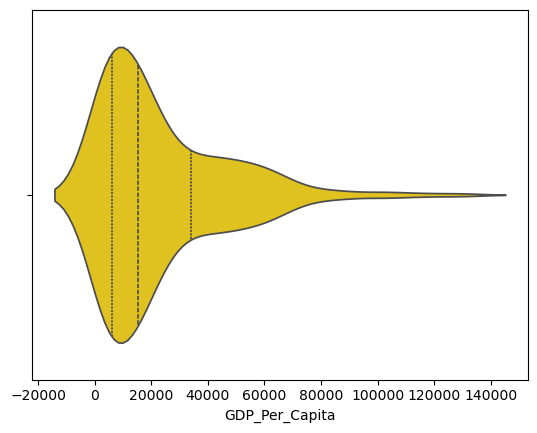

In [32]:
sns.violinplot(data=Data_2020, x='GDP_Per_Capita', color='gold', inner='quartile')

In [33]:
##What do you notice when you look at these plots? 

##ANSWER###### Some of these plots don't make any sense for this data (i.e. Violin Plot)
#### Density Plot & Violin Plot don't give exact numbers and need to be a continuous lines.

##How do the plots compare and what information can you get out of one type that you can't necessarily get out of the others?

####ANSWER#### the histogram is able to provide more specific data.the box plot gives a lot more data, which quartile has the highest concentration, points out any outliers and visually very easy to understand.

In [34]:
## 9. What was the median GDP per capita value in 2020?

median_value = Data_2020['GDP_Per_Capita'].median()

median_value

15399.308958012449

In [35]:
# 10. Create some visualizations to compare GDP per capita values for the years 
# 1990, 2000, 2010, and 2020. 
# Start by subsetting your data to just these 4 years into a new DataFrame named gdp_decades. 
# Using this, create the following 4 plots:
	# A boxplot
	# A barplot (check out the Barplot with Seaborn section: https://www.python-graph-gallery.com/barplot/#Seaborn)
	# A scatterplot
	# A scatterplot with a trend line overlaid (see this regplot example: https://www.python-graph-gallery.com/42-custom-linear-regression-fit-seaborn) 
# Comment on what you observe has happened to GDP values over time and the relative strengths and weaknesses of each type of plot.

In [188]:
my_decades = [1990, 2000, 2010, 2020]

In [189]:
my_decades

[1990, 2000, 2010, 2020]

In [190]:
gdp_decades = gdp_df[gdp_df['Year'].isin([1990, 2000, 2010, 2020])]

gdp_decades

,Country,Year,GDP_Per_Capita
3,Afghanistan,2020,2769.685745
13,Afghanistan,2010,2848.586061
23,Afghanistan,2000,1617.826475
28,Africa Eastern and Southern,2020,3978.931395
38,Africa Eastern and Southern,2010,3976.010989
...,...,...,...
8429,Zambia,1990,2425.111287
8434,Zimbabwe,2020,4527.719881
8444,Zimbabwe,2010,3885.393785
8454,Zimbabwe,2000,6170.333908


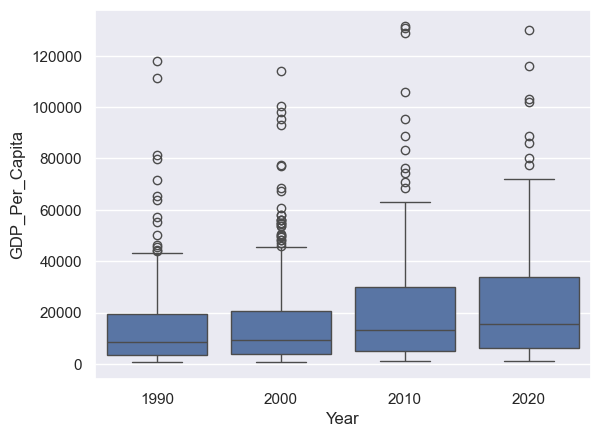

In [191]:
sns.boxplot(data = gdp_decades, x = 'Year', y = 'GDP_Per_Capita');

<Axes: xlabel='Year', ylabel='GDP_Per_Capita'>

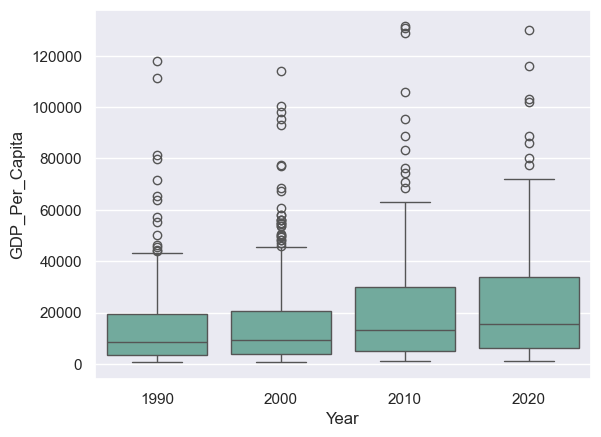

In [201]:
import seaborn as sns
import matplotlib.pyplot as plt

# dataset
gdp_decades = gdp_df[gdp_df['Year'].isin([1990, 2000, 2010, 2020])]

# chart type
sns.boxplot(
    data=gdp_decades, 
    x='Year', 
    y='GDP_Per_Capita',
    color='#69b3a2')

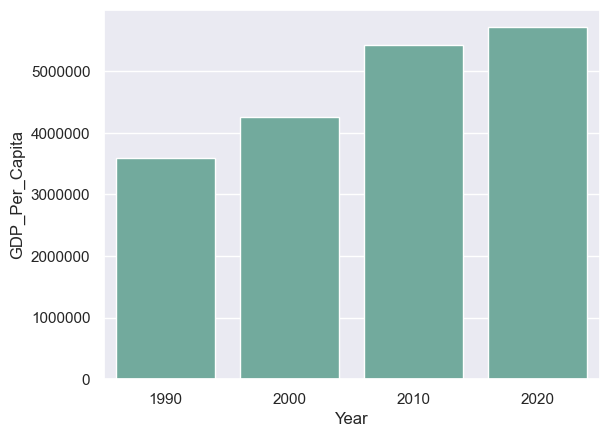

In [200]:
import seaborn as sns
import matplotlib.pyplot as plt

gdp_decades = gdp_df[gdp_df['Year'].isin([1990, 2000, 2010, 2020])]

sns.barplot(
    x="Year",
    y="GDP_Per_Capita", 
    data=gdp_decades, 
    estimator=sum, 
    errorbar=None,
    color='#69b3a2')

plt.ticklabel_format(style='plain', axis='y');

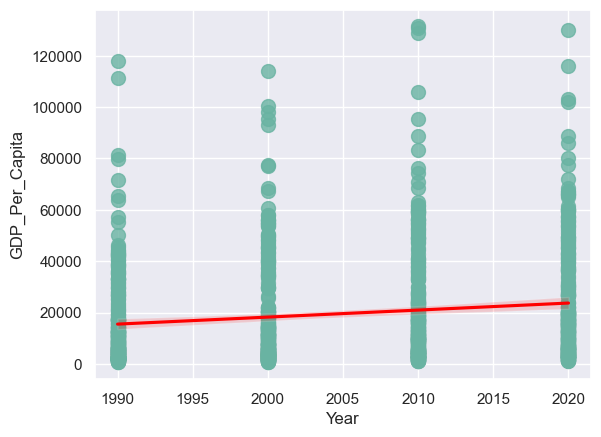

In [199]:
gdp_decades = gdp_df[gdp_df['Year'].isin([1990, 2000, 2010, 2020])]

sns.regplot(
    x= "Year", 
    y= "GDP_Per_Capita", 
    data= gdp_decades,
    color='#69b3a2',
    line_kws = {"color": "red"},
    scatter_kws = {"s": 100}
)

plt.show()

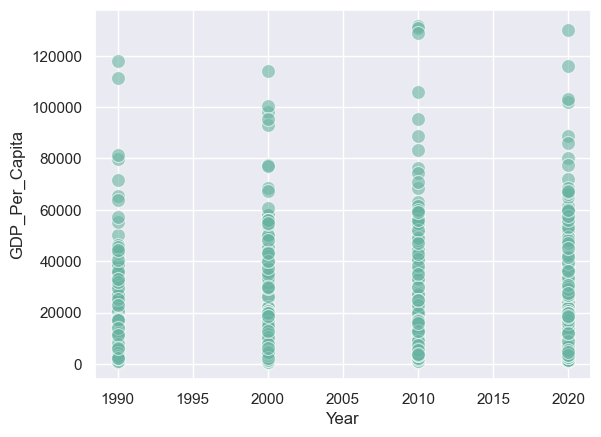

In [198]:
gdp_decades = gdp_df[gdp_df['Year'].isin([1990, 2000, 2010, 2020])]

sns.scatterplot(
    x="Year", 
    y="GDP_Per_Capita", 
    data=gdp_decades,
    color='#69b3a2',
    alpha=0.6, #makes points transparent
    s=100     
)

plt.show()

<Axes: xlabel='Year', ylabel='GDP_Per_Capita'>

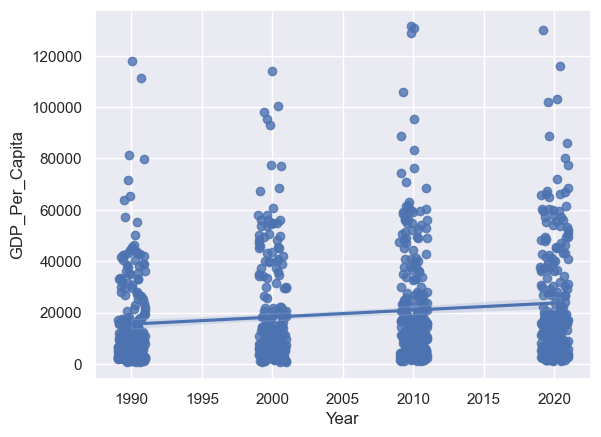

In [206]:
sns.regplot(data = gdp_decades, x = 'Year', y = 'GDP_Per_Capita', x_jitter = 1)


In [41]:
##ANSWER #10: GDP per Capita has steadily increased over the decades. The Median line correctly sits near the values where there is the greatest concentration (visually).
## The boxplot is very informative, showing outliers (which in this data is very relevant), all the quartiles of the data for that particular year. 
##Bar chart also does a good job of keeping this data simple, but combines the data for the entire year. So you're able to see the that GDP per Capita is increasing, but not all the individual instances of where the values lie, just the aggregate.

In [42]:

## 11. Which country was the first to have a GDP per capita greater than $100,000? 

In [209]:


rich_df = gdp_df.loc[gdp_df["GDP_Per_Capita"] > 100000]
rich_df

,Country,Year,GDP_Per_Capita
794,Bermuda,2024,109311.936941
795,Bermuda,2023,103052.348368
807,Bermuda,2011,101989.927296
808,Bermuda,2010,105968.875104
809,Bermuda,2009,108962.816946
...,...,...,...
8058,United Arab Emirates,1994,102456.104720
8059,United Arab Emirates,1993,100422.631522
8060,United Arab Emirates,1992,104206.754891
8061,United Arab Emirates,1991,106266.193694


In [211]:
min_year = rich_df.Year.min()

min_year

1990

In [213]:
rich_df.loc[gdp_df["GDP_Per_Capita"] > 100000].nsmallest(1, "Year")

,Country,Year,GDP_Per_Capita
1037,Brunei Darussalam,1990,118163.68337


In [45]:
gdp_df['Year'].dtype

dtype('int64')

In [46]:

## 12. Which country had the highest GDP per capita in 2020? 
##Create a plot showing how this country's GDP per capita has changed over the timespan of the dataset.

In [214]:
df_2020 = gdp_df[gdp_df['Year'] == 2020]

highest_gdp_2020 = df_2020.loc[df_2020["GDP_Per_Capita"].idxmax().round(2)]

rounded_highest_gdp_2020 = round(highest_gdp_2020["GDP_Per_Capita"], 2)

rounded_highest_gdp_2020

np.float64(129865.63)

In [215]:
Luxembourg_GDP = gdp_df.loc[gdp_df["Country"] == "Luxembourg"]

Luxembourg_GDP

,Country,Year,GDP_Per_Capita
4625,Luxembourg,2024,128475.279803
4626,Luxembourg,2023,130048.920388
4627,Luxembourg,2022,132570.826463
4628,Luxembourg,2021,136772.443753
4629,Luxembourg,2020,129865.629988
4630,Luxembourg,2019,132724.752744
4631,Luxembourg,2018,131733.884649
4632,Luxembourg,2017,132169.834045
4633,Luxembourg,2016,133661.649729
4634,Luxembourg,2015,130097.256180


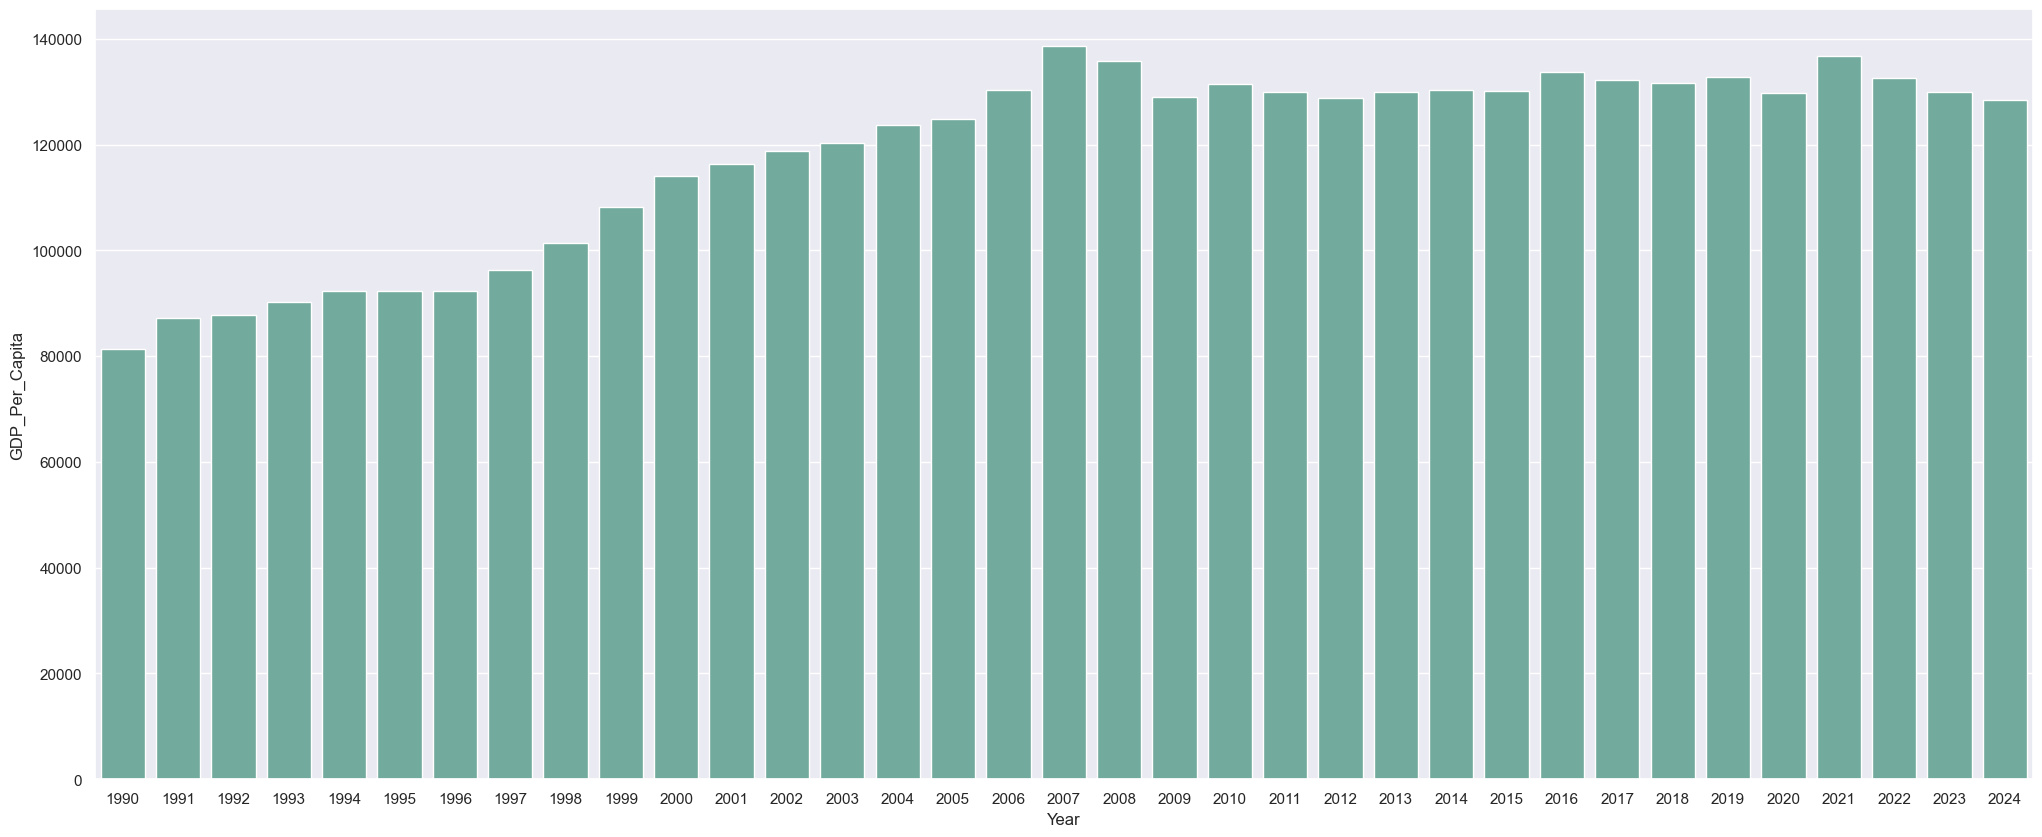

In [219]:
import seaborn as sns
import matplotlib.pyplot as plt

Luxembourg_GDP = gdp_df.loc[gdp_df["Country"] == "Luxembourg"]

plt.figure(figsize=(25, 10))

# plot a bar chart
sns.barplot(
    x="Year",
    y="GDP_Per_Capita", 
    data=Luxembourg_GDP, 
    estimator=sum, 
    errorbar=None,
    color='#69b3a2')

plt.ticklabel_format(style='plain', axis='y');

In [50]:
## 13. Which country had the lowest GDP per capita in 2020? 
##Create a plot showing how this country's GDP per capita has changed over the timespan of the dataset. 

lowest_gdp_2020 = df_2020.loc[df_2020["GDP_Per_Capita"].idxmin().round(2)]

rounded_lowest_gdp_2020 = round(lowest_gdp_2020["GDP_Per_Capita"], 2)

rounded_lowest_gdp_2020

np.float64(1030.77)

In [51]:
lowest_gdp_country = lowest_gdp_2020["Country"]

lowest_gdp_country

'Burundi'

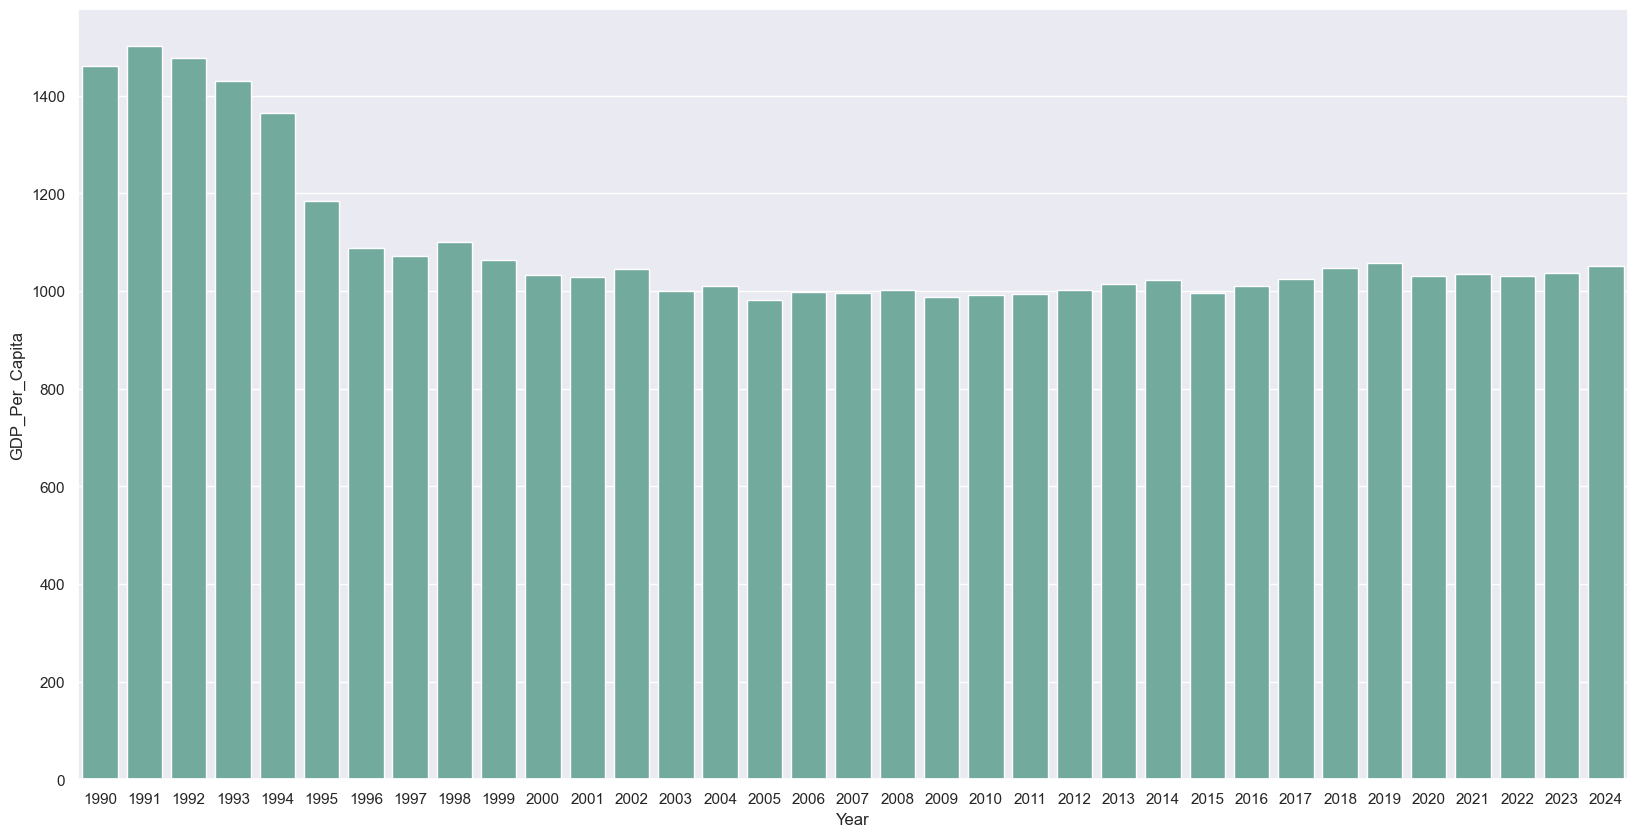

In [221]:
import seaborn as sns
import matplotlib.pyplot as plt

lowest_gdp_country = gdp_df.loc[gdp_df["Country"] == "Burundi"]

# Set the figure size
plt.figure(figsize=(20, 10))

# plot a bar chart
sns.barplot(
    x="Year",
    y="GDP_Per_Capita", 
    data=lowest_gdp_country, 
    estimator=sum, 
    errorbar=None,
    color='#69b3a2')

plt.ticklabel_format(style='plain', axis='y');

In [53]:
##**Bonus:** Is it true in general that countries had a higher GDP per capita in 2020 than in 1990? Which countries had lower GDP per capita in 2020 than in 1990?

In [54]:
Data_2020 = gdp_df[gdp_df['Year'] == 2020]
Data_1990 = gdp_df[gdp_df['Year'] == 1990]

Data_2020

,Country,Year,GDP_Per_Capita
3,Afghanistan,2020,2769.685745
28,Africa Eastern and Southern,2020,3978.931395
63,Africa Western and Central,2020,5687.849988
98,Albania,2020,15659.588696
133,Algeria,2020,14194.155748
...,...,...,...
8310,Virgin Islands (US),2020,45055.782930
8333,West Bank and Gaza,2020,5423.682547
8364,World,2020,18803.068884
8399,Zambia,2020,3391.595412


In [55]:
Data_1990

,Country,Year,GDP_Per_Capita
58,Africa Eastern and Southern,1990,3519.317545
93,Africa Western and Central,1990,4159.732102
128,Albania,1990,5291.156834
163,Algeria,1990,11728.545729
198,Andorra,1990,50036.300776
...,...,...,...
8272,Vanuatu,1990,3101.680551
8307,Viet Nam,1990,2467.964601
8394,World,1990,11250.325176
8429,Zambia,1990,2425.111287


In [223]:
gdp_merged = pd.merge(
        Data_1990,
        Data_2020,
        on='Country',
        suffixes=('_1990','_2020')
)

gdp_merged

,Country,Year_1990,GDP_Per_Capita_1990,Year_2020,GDP_Per_Capita_2020
0,Africa Eastern and Southern,1990,3519.317545,2020,3978.931395
1,Africa Western and Central,1990,4159.732102,2020,5687.849988
2,Albania,1990,5291.156834,2020,15659.588696
3,Algeria,1990,11728.545729,2020,14194.155748
4,Andorra,1990,50036.300776,2020,55488.490299
...,...,...,...,...,...
228,Vanuatu,1990,3101.680551,2020,3259.995438
229,Viet Nam,1990,2467.964601,2020,11851.396569
230,World,1990,11250.325176,2020,18803.068884
231,Zambia,1990,2425.111287,2020,3391.595412


In [224]:
Count_GDP_Greater2020 = (df_1990_2020['GDP_Per_Capita_2020'] > gdp_merged['GDP_Per_Capita_1990']).sum()

Count_GDP_Greater2020


np.int64(209)

In [225]:
Count_GDP_Greater1990 = (df_1990_2020['GDP_Per_Capita_2020'] < gdp_merged['GDP_Per_Capita_1990']).sum()

Count_GDP_Greater1990

np.int64(24)

In [226]:
Better_in_90s = df_1990_2020[df_1990_2020['GDP_Per_Capita_1990'] > gdp_merged['GDP_Per_Capita_2020']]

higher_1990_GDP_Countries = Better_in_90s['Country']

higher_1990_GDP_Countries

10                                        Aruba
14                                 Bahamas, The
17                                     Barbados
28                            Brunei Darussalam
31                                      Burundi
38                     Central African Republic
45                Congo, Democratic Republic of
46                           Congo, Republic of
72     Fragile and conflict affected situations
74                                        Gabon
86                                        Haiti
113                             Kyrgyz Republic
123                                     Liberia
124                                       Libya
131                                  Madagascar
146                                     Moldova
152                                       Nauru
184                                Saudi Arabia
199                                   St. Lucia
208                        Syrian Arab Republic
210                                  Taj

In [60]:
####BONUS ANSWER*****: most countries had GREATER GDP in 2020 than 1990, above are the 24 countries that are struggling since the 90s

In [61]:
## 14. Read in the internet use dataset into a DataFrame named `internet_df`. 
##You will likely get errors when doing this. 
##Check the arguments for the read_csv function to find ones that can help correct the errors (https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html) 
##Once you are able to read it in, take per a look at the top and bottom few rows to make sure that it has been read in correctly. 
##Also, check the datatypes of the columns.


pd.read_csv('../data/internet_use.csv', nrows=6083)

,Country or Area,Year,Value,Value Footnotes
0,Afghanistan,2019,17.600000,1
1,Afghanistan,2018,16.800000,2
2,Afghanistan,2017,13.500000,3
3,Afghanistan,2016,11.000000,4
4,Afghanistan,2015,8.260000,4
...,...,...,...,...
6078,Zimbabwe,1997,0.033080,NaN
6079,Zimbabwe,1996,0.016790,NaN
6080,Zimbabwe,1995,0.007684,NaN
6081,Zimbabwe,1994,0.001739,NaN


In [87]:
internet_use = pd.read_csv('../data/internet_use.csv', nrows=6083)
internet_use

,Country or Area,Year,Value,Value Footnotes
0,Afghanistan,2019,17.600000,1
1,Afghanistan,2018,16.800000,2
2,Afghanistan,2017,13.500000,3
3,Afghanistan,2016,11.000000,4
4,Afghanistan,2015,8.260000,4
...,...,...,...,...
6078,Zimbabwe,1997,0.033080,NaN
6079,Zimbabwe,1996,0.016790,NaN
6080,Zimbabwe,1995,0.007684,NaN
6081,Zimbabwe,1994,0.001739,NaN


In [90]:
print(internet_use['Value Footnotes'].dtype)

object


In [91]:
internet_use.columns

Index(['Country or Area', 'Year', 'Value', 'Value Footnotes'], dtype='object')

In [92]:
internet_use.dtypes

Country or Area     object
Year                 int64
Value              float64
Value Footnotes     object
dtype: object

In [62]:

##15. Drop the `Value Footnotes` column and rename the remaining three to 'Country', 'Year', and 'Internet_Users_Pct'.
int_use = internet_use.drop(columns=['Value Footnotes'])

In [96]:
int_use.columns = ['Country', 'Year', 'Internet_Users_Pct']

In [107]:
int_use

,Country,Year,Internet_Users_Pct
0,Afghanistan,2019,17.600000
1,Afghanistan,2018,16.800000
2,Afghanistan,2017,13.500000
3,Afghanistan,2016,11.000000
4,Afghanistan,2015,8.260000
...,...,...,...
6078,Zimbabwe,1997,0.033080
6079,Zimbabwe,1996,0.016790
6080,Zimbabwe,1995,0.007684
6081,Zimbabwe,1994,0.001739


In [116]:

##16. Look at the number of observations in this dataset per year. What do you notice?

int_use.groupby('Year')['Country'].count()

##ANSWER## The years 1991-1994 had a reduced number of countries observed. It's possible that the 1990 is just the baseline of most/all countries. Given there's 207 countries at "0", that means there were some early adopting countries



Year
1990    226
1991     39
1992     50
1993     66
1994     92
1995    141
1996    177
1997    188
1998    195
1999    207
2000    210
2001    212
2002    214
2003    208
2004    210
2005    212
2006    212
2007    217
2008    214
2009    214
2010    209
2011    214
2012    209
2013    203
2014    204
2015    203
2016    206
2017    205
2018    174
2019    185
2020    186
2021    186
2022    184
2023     11
Name: Country, dtype: int64

In [118]:

baseline_1990 = int_use[(int_use['Year'] == 1990) & (int_use['Internet_Users_Pct'] == 0)]

baseline_1990.shape[0]

207

In [129]:

##17. What is the first year to have a non-zero internet users percentage value?

non_zero_users = int_use[(int_use['Internet_Users_Pct'] > 0)]
non_zero_users

non_zero_users['Year'].min()

1990

In [135]:

##18. How does the distribution of internet users percent differ for 2000 and 2014?

##ANSWER: The distribution
int_use_in_2000 = int_use[(int_use['Year'] == 2000)]['Internet_Users_Pct'].median()

int_use_in_2000

2.88668

In [137]:
int_use_in_2014 = int_use[(int_use['Year'] == 2014)]['Internet_Users_Pct'].median()

int_use_in_2014

46.818

In [158]:

##19. For how many countries was the percentage of internet users below 5% in 2014?

##int_use[(int_use['Year'] == 2014) & (int_use['Internet_Users_Pct'] < 5)]

int_use[(int_use['Year'] == 2014) & (int_use['Internet_Users_Pct'] < 5)]['Country'].count()


np.int64(10)

In [67]:
##20. Merge the two DataFrames to one. 
##Do this in a way that keeps **all rows** from each of the two DataFrames. 
##Call the new DataFrame `gdp_and_internet_use`. 
##Look at the first and last few rows to confirm that it merged correctly.

gdp_and_internet_use = pd.merge (gdp_df, int_use, on='Year')gdp_df



In [68]:
##21. Find the three countries with the highest internet users percentage in 2014. Use a seaborn FacetGrid (https://seaborn.pydata.org/generated/seaborn.FacetGrid.html) to compare how the GDP per capita has changed over time for these three countries. What do you notice?


In [69]:
##22. Subset `gdp_and_internet_use` to just the year 2014. Save this as a new dataframe named `gdp_and_internet_use_2014`.

In [70]:
##23. Create a plot which compares Internet Users Percentage and GDP per Capita for the year 2014. What do you notice from this plot? If you see any unusual points, investigate them.


In [71]:
##24. **Stretch Question:** Use the `qcut` function from pandas (https://pandas.pydata.org/docs/reference/api/pandas.qcut.html) to divide countries in `gdp_per_capita_2014` into three groups based on their GDP per capita values. Label these groups as "Low", "Medium", and "High". Put these labels in a new column, named "GDP_group".


In [72]:
##25. **Stretch Question:** How does the median internet users percentage compare for the three gdp groups?



In [73]:
### Bonus exercise:
##1.    Download another data set from the UN data (http://data.un.org/Explorer.aspx) to merge with your data and explore.